100%|██████████| 170M/170M [00:03<00:00, 48.0MB/s]


Epoch: 1 | Training Loss: 2.191507052078247 | Training Accuracy: 20.168% | Validation Loss: 1.9506506172180176 | Validation Accuracy: 30.85%
Epoch: 5 | Training Loss: 1.6760581352233888 | Training Accuracy: 45.348% | Validation Loss: 1.4904467834472657 | Validation Accuracy: 53.410000000000004%
Epoch: 10 | Training Loss: 1.4338708641815185 | Training Accuracy: 58.252% | Validation Loss: 1.2105449295043946 | Validation Accuracy: 68.14%
Epoch: 15 | Training Loss: 1.2650407228088378 | Training Accuracy: 66.51% | Validation Loss: 1.0556246662139892 | Validation Accuracy: 75.85%
Epoch: 20 | Training Loss: 1.1713117025375366 | Training Accuracy: 71.088% | Validation Loss: 0.9440881637573242 | Validation Accuracy: 81.22%
Epoch: 25 | Training Loss: 1.1149323784255982 | Training Accuracy: 73.658% | Validation Loss: 0.9058426302909851 | Validation Accuracy: 82.80999999999999%
Epoch: 30 | Training Loss: 1.077441863632202 | Training Accuracy: 75.36% | Validation Loss: 0.8697793949127197 | Validati

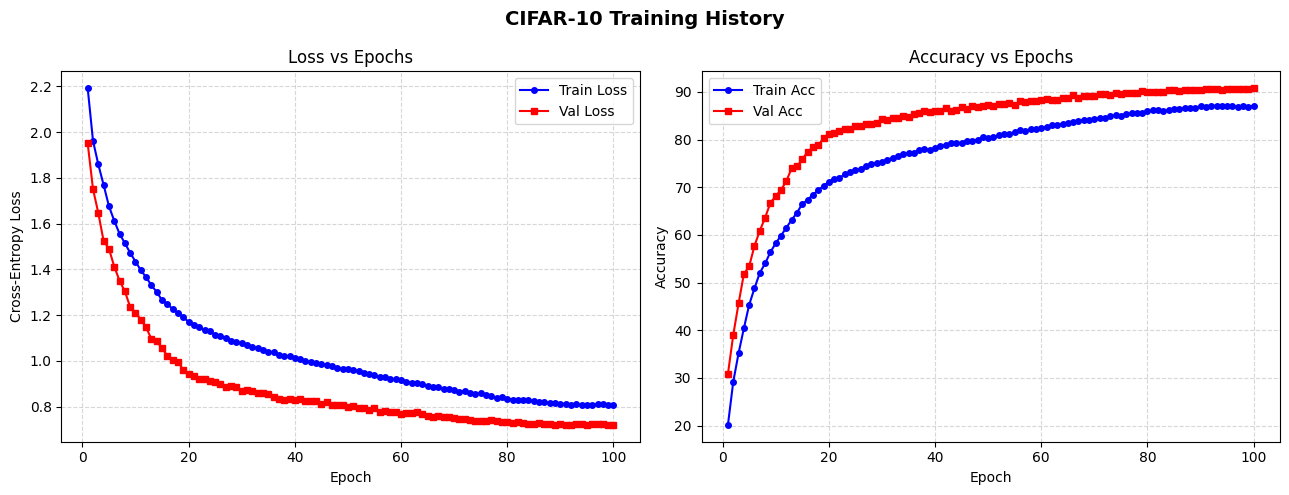

Plots saved successfully: training_curves_cnn.png


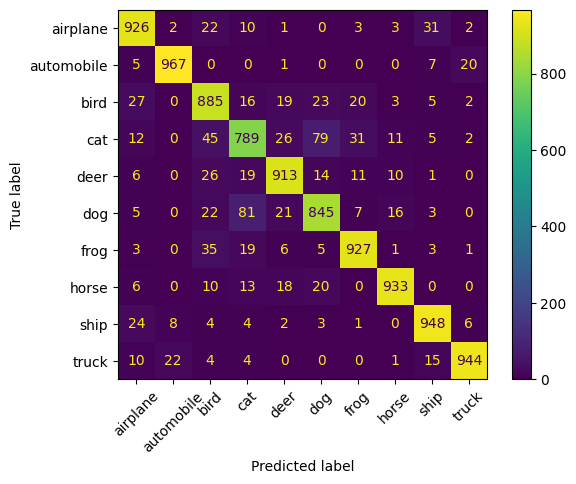

Confusion matrix created successfully: confusion_matrix_cnn.png
              precision    recall  f1-score   support

    airplane       0.90      0.93      0.92      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.84      0.89      0.86      1000
         cat       0.83      0.79      0.81      1000
        deer       0.91      0.91      0.91      1000
         dog       0.85      0.84      0.85      1000
        frog       0.93      0.93      0.93      1000
       horse       0.95      0.93      0.94      1000
        ship       0.93      0.95      0.94      1000
       truck       0.97      0.94      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Validation Loss: 0.7205783870697021  |  Validation Accuracy: 90.77%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LR= 1e-3 # Adam learning rate
WEIGHT_DECAY  = 1e-4 # L2 regularisation coefficient
DEVICE= torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.25)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
val_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

class ImageClassification(nn.Module):

    def __init__(self):
        super(ImageClassification, self).__init__()

        self.block111 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        self.block112 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
        )

        self.out11 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        self.block121 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.block122 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
        )

        self.proj1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32)
        )

        self.out12 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block211 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.block212 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        self.out21 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        self.proj2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64)
        )

        self.block221 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.block222 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        self.out22 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        self.block231 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.block232 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        self.out23 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block311 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.block312 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )

        self.out31 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        self.proj3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128)
        )

        self.block321 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.block322 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )

        self.out32 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        self.block331 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.block332 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )

        self.out33 = nn.Sequential(
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

        self.initialise_weights()

    def initialise_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x111 = self.block111(x)
        x112 = self.block112(x111)
        out11 = x112 + self.proj1(x)
        x121 = self.out11(out11)

        x122 = self.block121(x121)
        x123 = self.block122(x122)
        out12 = x123 + x121

        out1 = self.out12(out12)

        x211 = self.block211(out1)
        x212 = self.block212(x211)
        out21 = x212 + self.proj2(out1)
        x221 = self.out21(out21)

        x222 = self.block221(x221)
        x223 = self.block222(x222)
        out22 = x223 + x221
        x231 = self.out22(out22)

        x232 = self.block231(x231)
        x233 = self.block232(x232)
        out23 = x233 + x231

        out2 = self.out23(out23)

        x311 = self.block311(out2)
        x312 = self.block312(x311)
        out31 = x312 + self.proj3(out2)
        x321 = self.out31(out31)

        x322 = self.block321(x321)
        x323 = self.block322(x322)
        out32 = x323 + x321
        x331 = self.out32(out32)

        x332 = self.block331(x331)
        x333 = self.block332(x332)
        out33 = x333 + x331

        out3 = self.out33(out33)

        logits = self.classifier(out3)
        return logits

def train(model, loader, criterion, optimizer, device):
    """Run one full pass over the training set; return avg loss & accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model.forward(images)
        loss  = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total * 100.0


@torch.no_grad()
def evaluate(model, loader, criterion, device, predlabel, truelabel):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model.forward(images)
        loss   = criterion(logits, labels) #mean batch loss

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        for p in preds:
            predlabel.append(p.item())
        for l in labels:
            truelabel.append(l.item())

    return total_loss / total, correct / total * 100.0


model     = ImageClassification().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

best_val_acc = 0.0

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

for epoch in range(1, 101):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE, [], [])
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    if epoch%5==0 or epoch==1:
        print(f"Epoch: {epoch} | Training Loss: {train_loss} | Training Accuracy: {train_acc}% | Validation Loss: {val_loss} | Validation Accuracy: {val_acc}%")

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {}
        for k, v in model.state_dict().items():
            best_state[k] = v.cpu().clone()
print("\n")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

#Save model weights
weights_path = "model_weights.pkl"
with open(weights_path, "wb") as f:
    pickle.dump(best_state, f)
print(f"Best model weights saved: {weights_path}")

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

predlabel, truelabel = [], []
val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE, predlabel, truelabel)

#Training curves
epochs_range = range(1, 101)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CIFAR-10 Training History", fontsize=14, fontweight="bold")

# Loss plot
axes[0].plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "r-s", markersize=4, label="Val Loss")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Accuracy plot
axes[1].plot(epochs_range, history["train_acc"], "b-o", markersize=4, label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "r-s", markersize=4, label="Val Acc")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved successfully: training_curves_cnn.png")

#Confusion Matrix
cm = confusion_matrix(truelabel, predlabel)
display = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
display.plot(xticks_rotation=45)
plt.savefig("confusion_matrix_cnn.png")
plt.show()
print("Confusion matrix created successfully: confusion_matrix_cnn.png")

#Classification Report
print(classification_report(truelabel, predlabel, target_names=CLASS_NAMES))

#Final evaluation on validation set
val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE, [], [])
print(f"Validation Loss: {val_loss}  |  Validation Accuracy: {val_acc}%")